✅ Dataset chargé : 2423 lignes x 20 colonnes
   c0_x  c0_o  c1_x  c1_o  c2_x  c2_o  c3_x  c3_o  c4_x  c4_o  c5_x  c5_o  \
0     0     0     0     0     0     0     0     0     0     0     0     0   
1     1     0     0     1     0     0     0     0     0     0     0     0   
2     0     1     1     0     0     0     0     0     0     0     0     0   
3     1     0     0     0     0     1     0     0     0     0     0     0   
4     0     1     0     0     1     0     0     0     0     0     0     0   

   c6_x  c6_o  c7_x  c7_o  c8_x  c8_o  x_wins  is_draw  
0     0     0     0     0     0     0       0        1  
1     0     0     0     0     0     0       1        0  
2     0     0     0     0     0     0       0        1  
3     0     0     0     0     0     0       1        0  
4     0     0     0     0     0     0       1        0  

=== DISTRIBUTION DES CLASSES ===
x_wins  : x_wins
1    0.755262
0    0.244738
Name: proportion, dtype: float64
is_draw : is_draw
0    0.817994
1    0

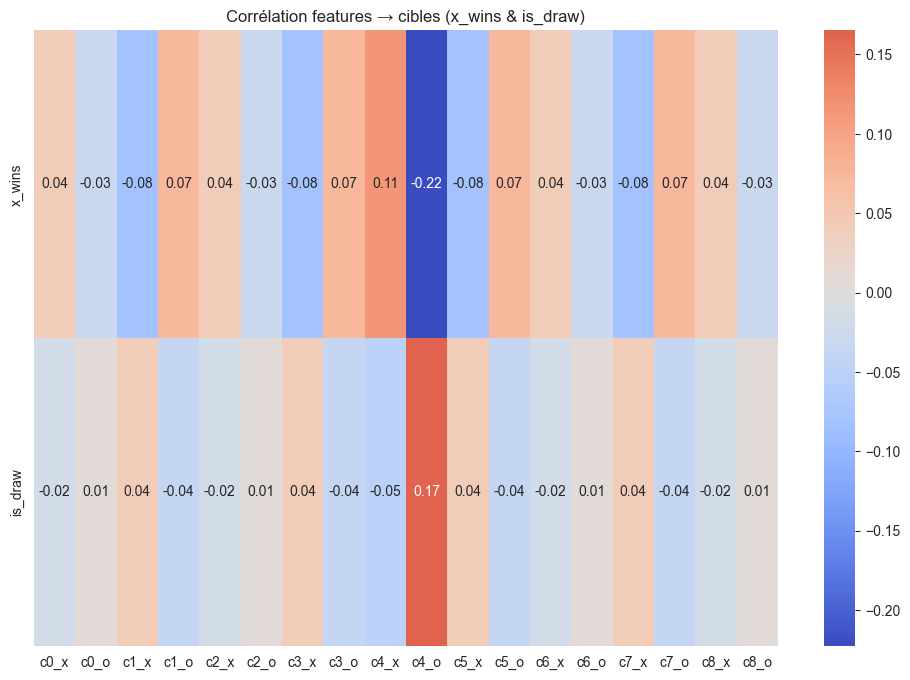


Top cases occupées par X quand il gagne :
  Cellule  Win_rate_X
4      c4    0.831461
0      c0    0.782669
2      c2    0.782669
6      c6    0.782669
8      c8    0.782669
1      c1    0.702156
3      c3    0.702156
5      c5    0.702156
7      c7    0.702156

=== BASELINE x_wins ===
Accuracy : 0.7773
F1-Score : 0.8686
              precision    recall  f1-score   support

           0       0.69      0.17      0.27       119
           1       0.78      0.98      0.87       366

    accuracy                           0.78       485
   macro avg       0.74      0.57      0.57       485
weighted avg       0.76      0.78      0.72       485


=== BASELINE is_draw ===
Accuracy : 0.8186
F1-Score : 0.0
              precision    recall  f1-score   support

           0       0.82      1.00      0.90       397
           1       0.00      0.00      0.00        88

    accuracy                           0.82       485
   macro avg       0.41      0.50      0.45       485
weighted avg      

c:\Users\tyt\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\tyt\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\tyt\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

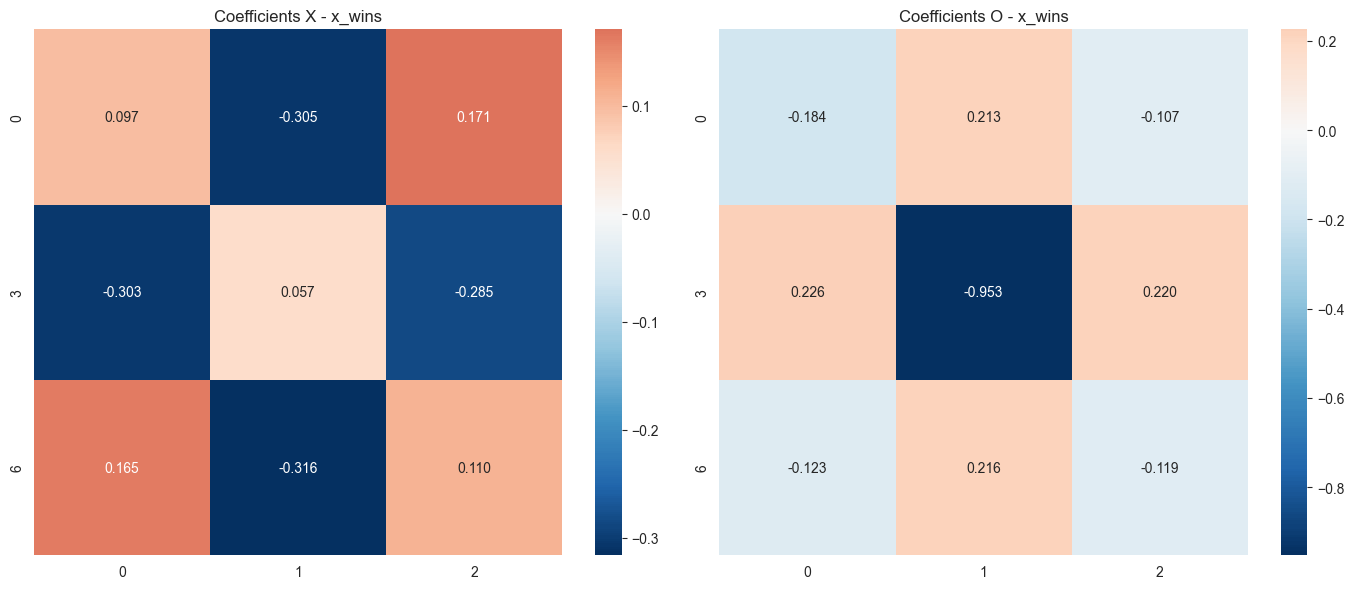

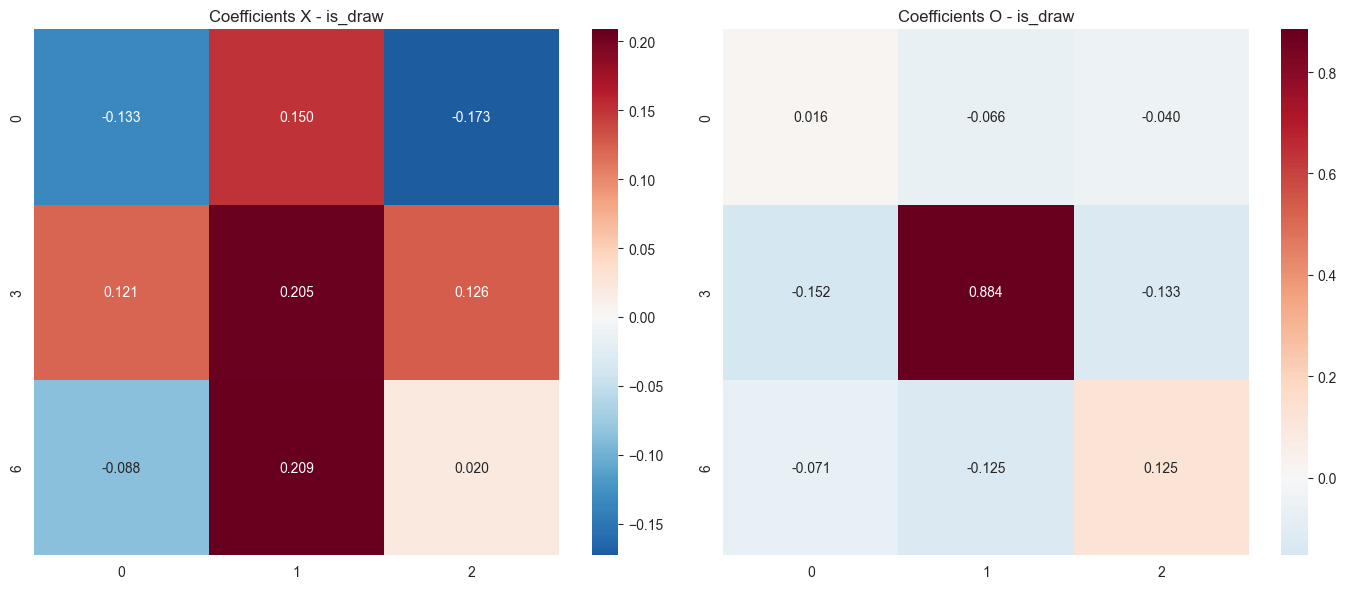

c:\Users\tyt\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:792: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")



=== COMPARAISON MODÈLES AVANCÉS ===
             Accuracy              F1        
Cible         is_draw  x_wins is_draw  x_wins
Modèle                                       
DecisionTree   0.8247  0.7753  0.4371  0.8525
MLP            0.9031  0.9320  0.7117  0.9556
RandomForest   0.8742  0.8639  0.4874  0.9158
XGBoost        0.9031  0.9423  0.6846  0.9624


In [13]:
# ================================================
# NOTEBOOK ML - MORPION (Hackathon ISPM)
# Structure respectée : notebooks/ + ressources/
# ================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 8)

# ====================== 1. CHARGEMENT DES DONNÉES ======================
df = pd.read_csv('../ressources/dataset.csv')   # ← chemin adapté à ta structure
print(f"✅ Dataset chargé : {df.shape[0]} lignes x {df.shape[1]} colonnes")
print(df.head())

X = df.iloc[:, :18]          # 18 features (c0_x ... c8_o)
y_win = df['x_wins']
y_draw = df['is_draw']

# ====================== 2. EDA (Étape 1) ======================
print("\n=== DISTRIBUTION DES CLASSES ===")
print("x_wins  :", y_win.value_counts(normalize=True))
print("is_draw :", y_draw.value_counts(normalize=True))

# Heatmap corrélation
plt.figure()
corr = pd.concat([X, y_win, y_draw], axis=1).corr()
sns.heatmap(corr.iloc[-2:,:18], annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title("Corrélation features → cibles (x_wins & is_draw)")
plt.show()

# Cases les plus importantes quand X gagne
x_cols = [col for col in X.columns if col.endswith('_x')]
win_rate = []
for col in x_cols:
    cell = col.replace('_x', '')
    rate = df[df[col] == 1]['x_wins'].mean()
    win_rate.append((cell, rate))

print("\nTop cases occupées par X quand il gagne :")
print(pd.DataFrame(win_rate, columns=['Cellule', 'Win_rate_X']).sort_values('Win_rate_X', ascending=False))

# ====================== 3. BASELINE : Logistic Regression ×2 (Étape 2) ======================
def train_baseline(y, name):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    print(f"\n=== BASELINE {name} ===")
    print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
    print("F1-Score :", round(f1_score(y_test, y_pred), 4))
    print(classification_report(y_test, y_pred))
    return model

model_win  = train_baseline(y_win,  "x_wins")
model_draw = train_baseline(y_draw, "is_draw")

# ====================== 4. ANALYSE DES COEFFICIENTS (obligatoire pour Q1) ======================
def plot_coefficients(model, title):
    coef = model.coef_[0].reshape(9, 2)   # 9 cases × (X, O)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for i, player in enumerate(['X', 'O']):
        data = coef[:, i].reshape(3, 3)
        sns.heatmap(data, annot=True, fmt=".3f", cmap="RdBu_r", center=0,
                    xticklabels=[0,1,2], yticklabels=[0,3,6], ax=axes[i])
        axes[i].set_title(f"Coefficients {player} - {title}")
    plt.tight_layout()
    plt.show()

print("\n=== CARTES DE COEFFICIENTS ===")
plot_coefficients(model_win,  "x_wins")
plot_coefficients(model_draw, "is_draw")

# ====================== 5. MODÈLES AVANCÉS (Étape 3) ======================
models = {
    "DecisionTree": DecisionTreeClassifier(max_depth=8, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'),
    "MLP": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
}

results = []
for name, model in models.items():
    for target_name, y in [("x_wins", y_win), ("is_draw", y_draw)]:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        results.append({
            "Modèle": name,
            "Cible": target_name,
            "Accuracy": round(accuracy_score(y_test, y_pred), 4),
            "F1": round(f1_score(y_test, y_pred), 4)
        })

results_df = pd.DataFrame(results)
print("\n=== COMPARAISON MODÈLES AVANCÉS ===")
print(results_df.pivot(index="Modèle", columns="Cible", values=["Accuracy", "F1"]))

In [15]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

joblib.dump(model_win,  '../models/model_win.pkl')
joblib.dump(model_draw, '../models/model_draw.pkl')

print("✅ Modèles sauvegardés dans ../models/")

✅ Modèles sauvegardés dans ../models/


In [16]:
import joblib
import os

# Création du dossier models à la racine
os.makedirs('../models', exist_ok=True)

# Sauvegarde des deux modèles
joblib.dump(model_win,  '../models/model_win.pkl')
joblib.dump(model_draw, '../models/model_draw.pkl')

print("✅ Modèles sauvegardés avec succès dans ../models/")
print("Fichiers créés :", os.listdir('../models'))

✅ Modèles sauvegardés avec succès dans ../models/
Fichiers créés : ['model_draw.pkl', 'model_win.pkl']


In [17]:
import joblib
import os

# Création du dossier models à la racine du projet
os.makedirs('../models', exist_ok=True)

# Sauvegarde des deux modèles (ils doivent exister dans le notebook)
joblib.dump(model_win,  '../models/model_win.pkl')
joblib.dump(model_draw, '../models/model_draw.pkl')

print("✅ Modèles sauvegardés avec succès !")
print("Dossier models contient :", os.listdir('../models'))

✅ Modèles sauvegardés avec succès !
Dossier models contient : ['model_draw.pkl', 'model_win.pkl']
